<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab5/blob/main/CH/VAC/VAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chua diode VAC

measured with signal generator and oscilloscope

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

Text(0, 0.5, 'V, V')

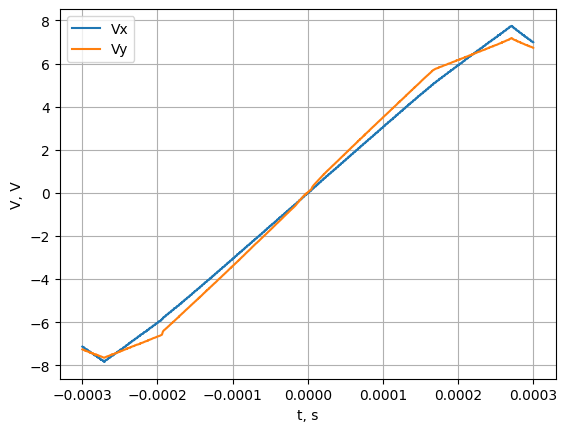

In [10]:
url = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab5/refs/heads/main/CH/VAC/VAC.csv'
t, v1, v2 = np.genfromtxt(url,  delimiter=',').T
plt.plot(t, v1, label='Vx')
plt.plot(t, v2, label='Vy')
plt.legend()
plt.grid()
plt.xlabel('t, s')
plt.ylabel('V, V')


Text(0, 0.5, 'I, mA')

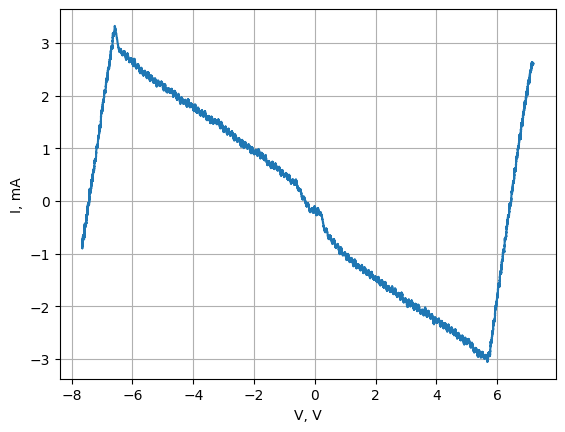

In [11]:
R = 216 #shunt
dV = v1 - v2
I = dV / R
V = v2
plt.plot(V, I*1e3)
plt.grid()
plt.xlabel('V, V')
plt.ylabel('I, mA')

Text(0, 0.5, 'I, mA')

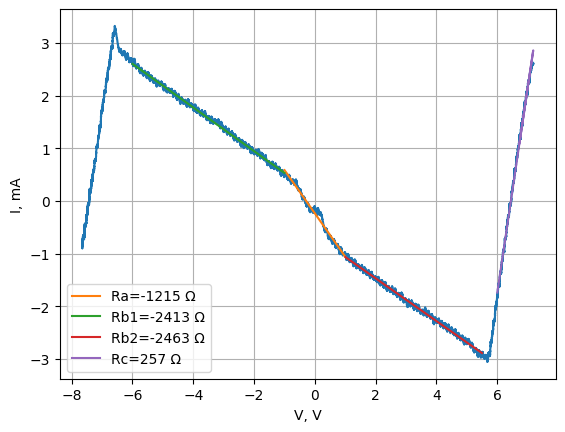

In [12]:
mask = (V > -1) & (V < 1)
fit = linregress(V[mask], I[mask])
plt.plot(V, I*1e3)
Ra = 1 / fit.slope
plt.plot(V[mask], (fit.slope*V[mask] + fit.intercept) *1e3, label=f'Ra={Ra:.0f} Ω' )
mask = (V >-6) & (V < -1)
fit = linregress(V[mask], I[mask])
Rb1 = 1 / fit.slope
plt.plot(V[mask], (fit.slope*V[mask] + fit.intercept) *1e3, label=f'Rb1={Rb1:.0f} Ω' )
mask = (V >1) & (V < 5.5)
fit = linregress(V[mask], I[mask])
Rb2 = 1 / fit.slope
plt.plot(V[mask], (fit.slope*V[mask] + fit.intercept) *1e3, label=f'Rb2={Rb2:.0f} Ω' )

mask = V >6
fit = linregress(V[mask], I[mask])
Rc = 1 / fit.slope
plt.plot(V[mask], (fit.slope*V[mask] + fit.intercept) *1e3, label=f'Rc={Rc:.0f} Ω' )


plt.legend()
plt.grid()
plt.xlabel('V, V')
plt.ylabel('I, mA')